In [10]:
import json
import pandas as pd
from pathlib import Path

In [ ]:
OUTPUTS_DIR = Path("logs/outputs")

rows = []

for run_dir in sorted(OUTPUTS_DIR.iterdir()):
    if not run_dir.is_dir():
        continue
    full_evals_dir = run_dir / "full_evals"
    if not full_evals_dir.exists():
        continue

    config_path = run_dir / "config.json"
    config = json.loads(config_path.read_text()) if config_path.exists() else {}

    # Flatten config into a single-level dict with dot-separated keys
    def flatten(d, prefix=""):
        out = {}
        for k, v in d.items():
            key = f"{prefix}{k}" if not prefix else f"{prefix}.{k}"
            if isinstance(v, dict):
                out.update(flatten(v, key))
            else:
                out[key] = v
        return out

    flat_config = flatten(config)

    num_params = None
    num_training_tokens = None
    report_path = run_dir / "base-model-training.md"
    if report_path.exists():
        for line in report_path.read_text().splitlines():
            if "Number of parameters:" in line:
                num_params = int(line.split("Number of parameters:")[1].strip().replace(",", ""))
            elif "Number of training tokens:" in line:
                num_training_tokens = int(line.split("Number of training tokens:")[1].strip().replace(",", ""))

    for eval_file in sorted(full_evals_dir.glob("*.json")):
        eval_data = json.loads(eval_file.read_text())

        row = {"run_id": run_dir.name, "num_params": num_params, "num_training_tokens": num_training_tokens}

        # Top-level scalar fields from eval
        for k, v in eval_data.items():
            if not isinstance(v, dict):
                row[f"eval.{k}"] = v

        # Flatten nested eval dicts (results, centered_results, etc.)
        for k, v in eval_data.items():
            if isinstance(v, dict):
                for task, score in v.items():
                    row[f"eval.{k}.{task}"] = score

        row.update(flat_config)
        rows.append(row)

df = pd.DataFrame(rows)
print(f"{len(df)} rows, {len(df.columns)} columns")
df.head()


In [3]:
# Quick overview of eval metrics vs model size
result_cols = [c for c in df.columns if c.startswith("eval.results.")]
df[["run_id", "eval.core_metric", "eval.step", "model.depth", "model.aspect_ratio"] + result_cols[:5]]

,run_id,eval.core_metric,eval.step,model.depth,model.aspect_ratio,eval.results.hellaswag_zeroshot,eval.results.jeopardy,eval.results.bigbench_qa_wikidata,eval.results.arc_easy,eval.results.arc_challenge
0,02f5xtcv,0.144648,2511,12,64,0.362378,0.008975,0.244722,0.572811,0.281570
1,0m2jxhzp,0.147053,8277,10,64,0.376319,0.014171,0.269918,0.581650,0.282423
2,3emsvyhr,0.096102,330,20,64,0.305417,0.001889,0.135377,0.485690,0.268771
3,8n47041l,0.179985,38497,10,64,0.403107,0.021256,0.330151,0.609007,0.310580
4,8pzz5vbz,0.138728,710,20,64,0.362478,0.008975,0.265194,0.554293,0.294369
5,d1hbiqyh,0.175640,3634,14,64,0.397431,0.020784,0.324787,0.593434,0.311433
6,d2wqpszm,0.206539,5582,16,64,0.450010,0.040624,0.377442,0.628788,0.336177
7,d796bqr2,0.195124,2030,18,64,0.435471,0.036845,0.374243,0.624158,0.320819
8,dhds26kd,0.179977,5398,12,64,0.396634,0.012754,0.284189,0.591330,0.307167
9,edwdnb94,0.179650,2587,16,64,0.400617,0.022201,0.339403,0.604377,0.303754


In [4]:
scaling_law_sanity = df[df["log.sweep_id"] == "scaling_law_sanity"].reset_index(drop=True)
print(f"{len(scaling_law_sanity)} rows")
scaling_law_sanity

24 rows


,run_id,num_params,eval.run_id,eval.step,eval.max_per_task,eval.core_metric,eval.samples,eval.results.hellaswag_zeroshot,eval.results.jeopardy,eval.results.bigbench_qa_wikidata,...,eval.core_metric_every,eval.core_metric_max_per_task,eval.sample_every,log.save_every,log.model_tag,log.run,log.wandb_project,log.wandb_entity,log.sweep_id,runtime.device_type
0,02f5xtcv,286261730,02f5xtcv,2511,-1,0.144648,"[{'prompt': 'The capital of France is', 'compl...",0.362378,0.008975,0.244722,...,999999,-1,-1,-1,None,None,nanochat,guillaume-lajoie,scaling_law_sanity,
1,0m2jxhzp,195952986,0m2jxhzp,8277,-1,0.147053,"[{'prompt': 'The capital of France is', 'compl...",0.376319,0.014171,0.269918,...,999999,-1,-1,-1,None,None,nanochat,guillaume-lajoie,scaling_law_sanity,
2,3emsvyhr,896533746,3emsvyhr,330,-1,0.096102,"[{'prompt': 'The capital of France is', 'compl...",0.305417,0.001889,0.135377,...,999999,-1,-1,-1,None,None,nanochat,guillaume-lajoie,scaling_law_sanity,
3,8n47041l,195952986,8n47041l,38497,-1,0.179985,"[{'prompt': 'The capital of France is', 'compl...",0.403107,0.021256,0.330151,...,999999,-1,-1,-1,None,None,nanochat,guillaume-lajoie,scaling_law_sanity,
4,8pzz5vbz,896533746,8pzz5vbz,710,-1,0.138728,"[{'prompt': 'The capital of France is', 'compl...",0.362478,0.008975,0.265194,...,999999,-1,-1,-1,None,None,nanochat,guillaume-lajoie,scaling_law_sanity,
5,d1hbiqyh,399114882,d1hbiqyh,3634,-1,0.175640,"[{'prompt': 'The capital of France is', 'compl...",0.397431,0.020784,0.324787,...,999999,-1,-1,-1,None,None,nanochat,guillaume-lajoie,scaling_law_sanity,
6,d2wqpszm,536871738,d2wqpszm,5582,-1,0.206539,"[{'prompt': 'The capital of France is', 'compl...",0.450010,0.040624,0.377442,...,999999,-1,-1,-1,None,None,nanochat,guillaume-lajoie,scaling_law_sanity,
7,d796bqr2,701891594,d796bqr2,2030,-1,0.195124,"[{'prompt': 'The capital of France is', 'compl...",0.435471,0.036845,0.374243,...,999999,-1,-1,-1,None,None,nanochat,guillaume-lajoie,scaling_law_sanity,
8,dhds26kd,286261730,dhds26kd,5398,-1,0.179977,"[{'prompt': 'The capital of France is', 'compl...",0.396634,0.012754,0.284189,...,999999,-1,-1,-1,None,None,nanochat,guillaume-lajoie,scaling_law_sanity,
9,edwdnb94,536871738,edwdnb94,2587,-1,0.179650,"[{'prompt': 'The capital of France is', 'compl...",0.400617,0.022201,0.339403,...,999999,-1,-1,-1,None,None,nanochat,guillaume-lajoie,scaling_law_sanity,


In [5]:
scaling_law_sanity.to_csv("logs/scaling_law_sanity.csv", index=False)
print("Saved to logs/scaling_law_sanity.csv")


Saved to logs/scaling_law_sanity.csv


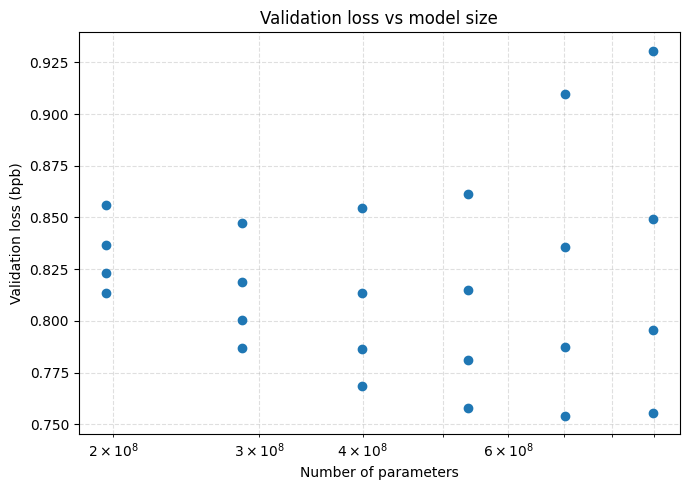

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(scaling_law_sanity["num_params"], scaling_law_sanity["eval.bpb.val"], zorder=3)

ax.set_xscale("log", base=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"$10^{{{np.log10(x):.1f}}}$"))
ax.set_xlabel("Number of parameters")
ax.set_ylabel("Validation loss (bpb)")
ax.set_title("Validation loss vs model size")
ax.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()


In [9]:
scaling_law_sanity.columns

Index(['run_id', 'num_params', 'eval.run_id', 'eval.step', 'eval.max_per_task',
       'eval.core_metric', 'eval.samples', 'eval.results.hellaswag_zeroshot',
       'eval.results.jeopardy', 'eval.results.bigbench_qa_wikidata',
       'eval.results.arc_easy', 'eval.results.arc_challenge',
       'eval.results.copa', 'eval.results.commonsense_qa', 'eval.results.piqa',
       'eval.results.openbook_qa', 'eval.results.lambada_openai',
       'eval.results.hellaswag', 'eval.results.winograd',
       'eval.results.winogrande', 'eval.results.bigbench_dyck_languages',
       'eval.results.agi_eval_lsat_ar', 'eval.results.bigbench_cs_algorithms',
       'eval.results.bigbench_operators',
       'eval.results.bigbench_repeat_copy_logic', 'eval.results.squad',
       'eval.results.coqa', 'eval.results.boolq',
       'eval.results.bigbench_language_identification',
       'eval.centered_results.hellaswag_zeroshot',
       'eval.centered_results.jeopardy',
       'eval.centered_results.bigbench_qa_

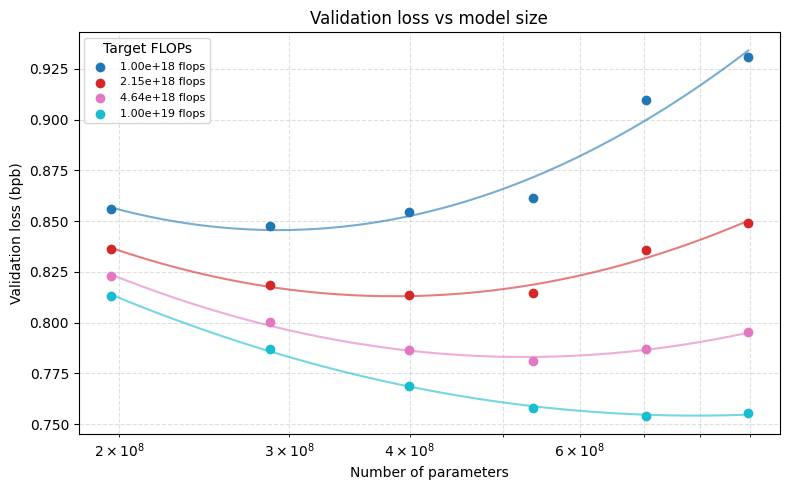

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

flop_groups = scaling_law_sanity.groupby("horizon.target_flops")
colors = plt.cm.tab10(np.linspace(0, 1, len(flop_groups)))

for (target_flops, group), color in zip(flop_groups, colors):
    group = group.sort_values("num_params")
    ax.scatter(group["num_params"], group["eval.bpb.val"], color=color, zorder=3,
               label=f"{target_flops:.2e} flops")
    if len(group) > 1:
        x = np.log10(group["num_params"].values)
        y = group["eval.bpb.val"].values
        coeffs = np.polyfit(x, y, deg=2)
        x_smooth = np.linspace(x.min(), x.max(), 200)
        ax.plot(10**x_smooth, np.polyval(coeffs, x_smooth), color=color, alpha=0.6)

ax.set_xscale("log", base=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"$10^{{{np.log10(x):.1f}}}$"))
ax.set_xlabel("Number of parameters")
ax.set_ylabel("Validation loss (bpb)")
ax.set_title("Validation loss vs model size")
ax.legend(title="Target FLOPs", fontsize=8)
ax.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()


 target_flops  optimal_params  optimal_bpb
 1.000000e+18    2.921089e+08     0.845606
 2.150000e+18    3.855274e+08     0.813015
 4.640000e+18    5.252729e+08     0.783085
 1.000000e+19    7.916036e+08     0.754211

Power law fit: N* ∝ C^0.430


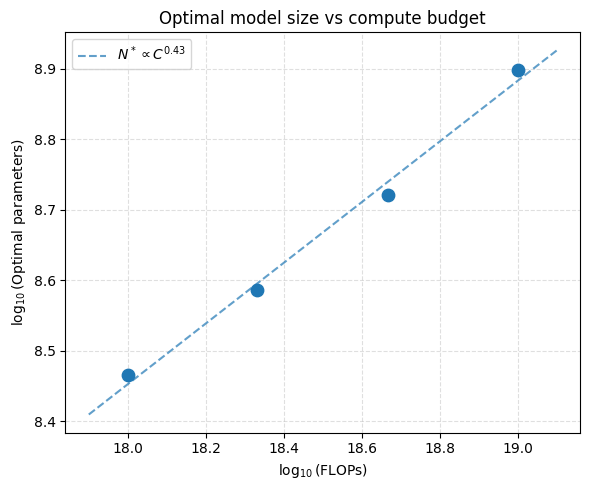

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# For each FLOPs group, fit a parabola in log10(params) space and find the vertex (minimum)
optimal_points = []

for target_flops, group in scaling_law_sanity.groupby("horizon.target_flops"):
    if len(group) < 3:
        continue  # need at least 3 points to fit a parabola
    x = np.log10(group["num_params"].values)
    y = group["eval.bpb.val"].values
    a, b, c = np.polyfit(x, y, deg=2)
    if a <= 0:
        continue  # not a proper concave-up parabola
    x_opt = -b / (2 * a)  # vertex: d/dx (ax^2 + bx + c) = 0 => x = -b/2a
    optimal_points.append({
        "target_flops": target_flops,
        "log_flops": np.log10(target_flops),
        "log_optimal_params": x_opt,
        "optimal_params": 10**x_opt,
        "optimal_bpb": np.polyval([a, b, c], x_opt),
    })

opt_df = pd.DataFrame(optimal_points).sort_values("log_flops")
print(opt_df[["target_flops", "optimal_params", "optimal_bpb"]].to_string(index=False))

# Fit a power law: log(N*) = alpha * log(C) + beta
log_f = opt_df["log_flops"].values
log_n = opt_df["log_optimal_params"].values
slope, intercept = np.polyfit(log_f, log_n, 1)
print(f"\nPower law fit: N* ∝ C^{slope:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(log_f, log_n, zorder=3, s=80)

f_smooth = np.linspace(log_f.min() - 0.1, log_f.max() + 0.1, 200)
ax.plot(f_smooth, np.polyval([slope, intercept], f_smooth), "--", alpha=0.7,
        label=f"$N^* \\propto C^{{{slope:.2f}}}$")

ax.set_xlabel("$\\log_{{10}}$(FLOPs)")
ax.set_ylabel("$\\log_{{10}}$(Optimal parameters)")
ax.set_title("Optimal model size vs compute budget")
ax.legend()
ax.grid(True, ls="--", alpha=0.4)

plt.tight_layout()
plt.show()


Power law fit: D* ∝ C^0.507


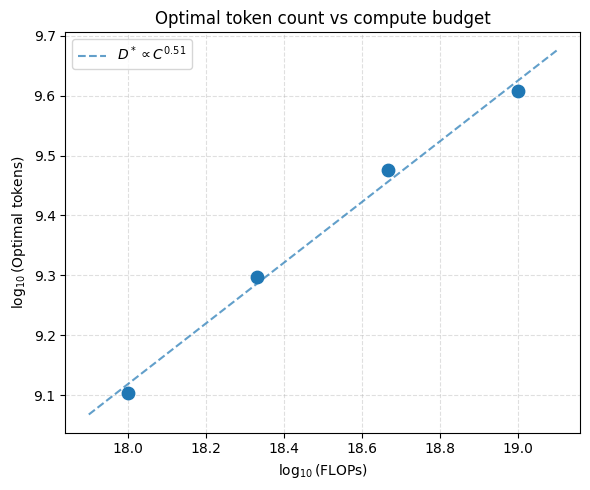

In [18]:
# Same parabola-vertex approach but over log10(num_training_tokens)
optimal_tokens_points = []

for target_flops, group in scaling_law_sanity.groupby("horizon.target_flops"):
    if len(group) < 3:
        continue
    x = np.log10(group["num_training_tokens"].values)
    y = group["eval.bpb.val"].values
    a, b, c = np.polyfit(x, y, deg=2)
    if a <= 0:
        continue
    x_opt = -b / (2 * a)
    optimal_tokens_points.append({
        "target_flops": target_flops,
        "log_flops": np.log10(target_flops),
        "log_optimal_tokens": x_opt,
        "optimal_tokens": 10**x_opt,
    })

opt_tokens_df = pd.DataFrame(optimal_tokens_points).sort_values("log_flops")

log_f = opt_tokens_df["log_flops"].values
log_t = opt_tokens_df["log_optimal_tokens"].values
slope, intercept = np.polyfit(log_f, log_t, 1)
print(f"Power law fit: D* ∝ C^{slope:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(log_f, log_t, zorder=3, s=80)

f_smooth = np.linspace(log_f.min() - 0.1, log_f.max() + 0.1, 200)
ax.plot(f_smooth, np.polyval([slope, intercept], f_smooth), "--", alpha=0.7,
        label=f"$D^* \\propto C^{{{slope:.2f}}}$")

ax.set_xlabel("$\\log_{{10}}$(FLOPs)")
ax.set_ylabel("$\\log_{{10}}$(Optimal tokens)")
ax.set_title("Optimal token count vs compute budget")
ax.legend()
ax.grid(True, ls="--", alpha=0.4)

plt.tight_layout()
plt.show()
